In [10]:
import networkx as nx
import random
import numpy as np
import itertools
import re
from collections import Counter
import seaborn as sns
import pandas as pd
import pickle 
import matplotlib.pyplot as plt

In [12]:
stage_labels = ['L1-0', 'L1-5', 'L1-8', 'L1-16', 'L2', 'L3', 'Ad-45-1', 'Ad-45-2']

In [14]:
stage_labels_plot = ['L1$_{0h}$', 'L1$_{5h}$', 'L1$_{8h}$', 'L1$_{16h}$', 'L2', 'L3', 'Ad$^{1}$', 'Ad$^{2}$']

In [28]:
# It tells Matplotlib's mathtext engine to render math upright (roman) instead of the default italics — 
# without needing to wrap your labels in \mathrm{} or edit the list.
plt.rcParams['mathtext.default'] = 'regular' 

In [16]:
with open('data/processed/all_c_elegans_weighted_graphs.pkl', 'rb') as file:
    all_c_elegans_weighted_graphs = pickle.load(file)

**The group behind the paper, "A simulated annealing algorithm for randomizing weighted networks" has put up a github repo of the code which I then used to randomize directed, weighted networks. I observed this method works better than directed edge swapping so I used it for unweighted networks as well.
https://github.com/netneurolab/milisav_strength_nulls/tree/main/code**

In [4]:
with open('data/processed/C_elegans_L1_0_1000_random_null_models.pkl', 'rb') as file:
    L1_0_randomised_graphs_relabeled = pickle.load(file)

with open('data/processed/C_elegans_L1_5_1000_random_null_models.pkl', 'rb') as file:
    L1_5_randomised_graphs_relabeled = pickle.load(file)

In [5]:
with open('data/processed/C_elegans_L1_8_1000_random_null_models.pkl', 'rb') as file:
    L1_8_randomised_graphs_relabeled = pickle.load(file)

with open('data/processed/C_elegans_L1_16_1000_random_null_models.pkl', 'rb') as file:
    L1_16_randomised_graphs_relabeled = pickle.load(file)

In [6]:
with open('data/processed/C_elegans_L2_1000_random_null_models.pkl', 'rb') as file:
    L2_randomised_graphs_relabeled = pickle.load(file)

with open('data/processed/C_elegans_L3_1000_random_null_models.pkl', 'rb') as file:
    L3_randomised_graphs_relabeled = pickle.load(file)

In [7]:
with open('data/processed/C_elegans_Ad_45_1_1000_random_null_models.pkl', 'rb') as file:
    Ad_45_1_randomised_graphs_relabeled = pickle.load(file)

with open('data/processed/C_elegans_Ad_45_2_1000_random_null_models.pkl', 'rb') as file:
    Ad_45_2_randomised_graphs_relabeled = pickle.load(file)

In [8]:
all_randomized_graphs_lists = [L1_0_randomised_graphs_relabeled, L1_5_randomised_graphs_relabeled, 
                               L1_8_randomised_graphs_relabeled, L1_16_randomised_graphs_relabeled,
                               L2_randomised_graphs_relabeled, L3_randomised_graphs_relabeled,
                               Ad_45_1_randomised_graphs_relabeled, Ad_45_2_randomised_graphs_relabeled]

## Plotting all stages for in-degree 

_In my algorithm, I have taken subgraphs of nodes having degree greater than k. There's no consistency in the literature regarding this. I have followed the Towlson paper on C. elegans rich club (same way done in "Rich-Club Organization of the Human Connectome"). But in "Rich-club neurocircuitry: function, evolution, and vulnerability" they have taken nodes with degree >= k. So, I think, either is fine._

In [25]:
# this took at least an hour AFAIR

rich_club_data = []
undefined_norm_RCC = {}
for i in range(8):
    empirical_graph = all_c_elegans_weighted_graphs[i]
    random_graphs = all_randomized_graphs_lists[i]

    weighted_in_degrees = dict(empirical_graph.in_degree(weight='weight'))
    unique_sin_vals = sorted(set(int(d) for d in weighted_in_degrees.values()))

    phi_norm = []
    phi_norm_err = []
    valid_k_vals = []
    undefined = []

    for k in unique_sin_vals:
        rich_nodes_emp = [n for n, d in weighted_in_degrees.items() if d > k]
        if len(rich_nodes_emp) < 2:
            continue

        subgraph_emp = empirical_graph.subgraph(rich_nodes_emp)
        w_emp = sum(d['weight'] for u, v, d in subgraph_emp.edges(data=True))

        rand_sums = []
        for G in random_graphs:
            weighted_in_degrees_rand = dict(G.in_degree(weight='weight'))
            rich_nodes_rand = [n for n, d in weighted_in_degrees_rand.items() if d > k]
            subgraph_rand = G.subgraph(rich_nodes_rand)
            w_rand = sum(d['weight'] for u, v, d in subgraph_rand.edges(data=True))
            rand_sums.append(w_rand)

        mean_rand = np.mean(rand_sums)
        std_rand = np.std(rand_sums)

        if mean_rand > 0:
            ratio = w_emp / mean_rand
            err = ratio * (std_rand / mean_rand)
        else:
            ratio = 1 # setting this to 1 as per the paper, "Rich-club and page-club coefficients for directed graphs"
            err = 0
            undefined.append((k,  w_emp))
            
        valid_k_vals.append(k)
        phi_norm.append(ratio)
        phi_norm_err.append(err)

    rich_club_data.append({
        'stage': stage_labels[i],
        'k_vals': valid_k_vals,
        'phi_norm': phi_norm,
        'phi_norm_err': phi_norm_err,
        'undefined': undefined
    })

#with open("data/processed/C_elegans_normalized_in_degree_weighted_rcc_all_networks.pkl", "wb") as f:
    #pickle.dump(rich_club_data, f)

In [18]:
with open("data/processed/C_elegans_normalized_in_degree_weighted_rcc_all_networks.pkl", "rb") as f:
    rich_club_data_in_degree = pickle.load(f)

In [20]:
rich_club_data_in_degree

[{'stage': 'L1-0',
  'k_vals': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   19,
   20,
   22,
   23,
   24,
   25,
   27,
   29,
   30,
   32,
   33],
  'phi_norm': [1.0004453255312067,
   0.9999373143442979,
   1.0181028494036743,
   1.0344523262156262,
   1.0637199902783652,
   1.079615257256053,
   1.1131104525679143,
   1.121920996667727,
   1.1282008197459148,
   1.17739681819149,
   1.1889625270517103,
   1.1976800184258465,
   1.1490007796791004,
   1.18127922002296,
   1.2077916874166423,
   1.3106408843976751,
   1.3946812544006932,
   1.3862204820156132,
   1.4627531790858326,
   1.5662269735896774,
   1.5474885550325617,
   1.6154515275780652,
   1.66015625,
   1.621537573024723,
   1.7637836425398485,
   1.07138829367317,
   1.2462784740012463,
   1.7621145374449338,
   3.872966692486445],
  'phi_norm_err': [0.001059590070671162,
   0.010500937963450486,
   0.013455368031021804,
   0.020963852512517398,

In [6]:
# phi_norm is never 0 for any stage so we can say that mean_random_rcc also was never 0 for any stage
for idx, stage_rcc_dict in enumerate(rich_club_data_in_degree):
    phi_norm = stage_rcc_dict['phi_norm']
    if 0 in set(phi_norm):
        print(stage_labels[idx], ' has a threshold for which phi norm is 0')

L1-5  has a threshold for which phi norm is 0


### Degree threshold for rich club phenomenon is found using those values of k for which we see that  $ \phi_{norm(k)} - \sigma_{\phi_{norm(k)}} > 1 $ . This is similar to the method used in the towlson paper (The Rich Club of the C.elegans Neuronal Connectome) . 

In [7]:
# initiallly regime is CLOSED so at every step check if statement is True then add the idx and make regime 'OPEN' 
# then close the regime at the first instance of idx where statement is False
# repeat the above

In [22]:
def pair_up(lst):
    
    '''Given a list of numbers, this function pairs up the items into tuples. Second element of the last tuple is None in
       case the list has odd number of items. '''
    
    paired = []
    for i in range(0, len(lst), 2):
        first = lst[i]
        second = lst[i+1] if i+1 < len(lst) else None
        paired.append((first, second))
    return paired


In [24]:
stages_regimes_in_degree = []
for dictionary in rich_club_data_in_degree:
    stage = dictionary['stage']
    size = len(dictionary['k_vals'])
    regime = 'CLOSE'
    all_regimes = []
    for idx in range(size):
        norm, err = dictionary['phi_norm'][idx], dictionary['phi_norm_err'][idx]
        statement = bool( (norm - err) >= 1)
            
        if regime == 'CLOSE' and statement == True:
            degree = dictionary['k_vals'][idx]
            all_regimes.append(degree)
            regime = 'OPEN'
            
        if regime == 'OPEN' and statement == False:
            degree = dictionary['k_vals'][idx-1]
            all_regimes.append(degree)
            regime = 'CLOSE'
        
    
    undefined_degree_points = [k for (k, _) in dictionary['undefined']]
    print(stage, all_regimes, undefined_degree_points)
    
    # confirming that undefined norm rcc is not mistakenly appearing in the middle of a regime. It's not. 
    if undefined_degree_points == True and all_regimes[-1] > min(undefined_degree_points): 
        print('\t', 'WARNING', undefined_degree_points)
        
    # Then I check the end of the last regime gives undefined norm RCC & if it does then I pop it out before pairing into tuples
    if undefined_degree_points:
        all_regimes.pop()
        
    print('    ', all_regimes)
    all_regimes = pair_up(all_regimes)
    stages_regimes_in_degree.append(all_regimes)
    
    print(all_regimes)
    print('\n')

L1-0 [2, 27] []
     [2, 27]
[(2, 27)]


L1-5 [3, 3, 6, 6, 8, 41] []
     [3, 3, 6, 6, 8, 41]
[(3, 3), (6, 6), (8, 41)]


L1-8 [5, 43] []
     [5, 43]
[(5, 43)]


L1-16 [6, 50] []
     [6, 50]
[(6, 50)]


L2 [8, 72] []
     [8, 72]
[(8, 72)]


L3 [8, 74] []
     [8, 74]
[(8, 74)]


Ad-45-1 [13, 108] []
     [13, 108]
[(13, 108)]


Ad-45-2 [11, 11, 13, 126] []
     [11, 11, 13, 126]
[(11, 11), (13, 126)]




### Plots with rich club regime dilineated

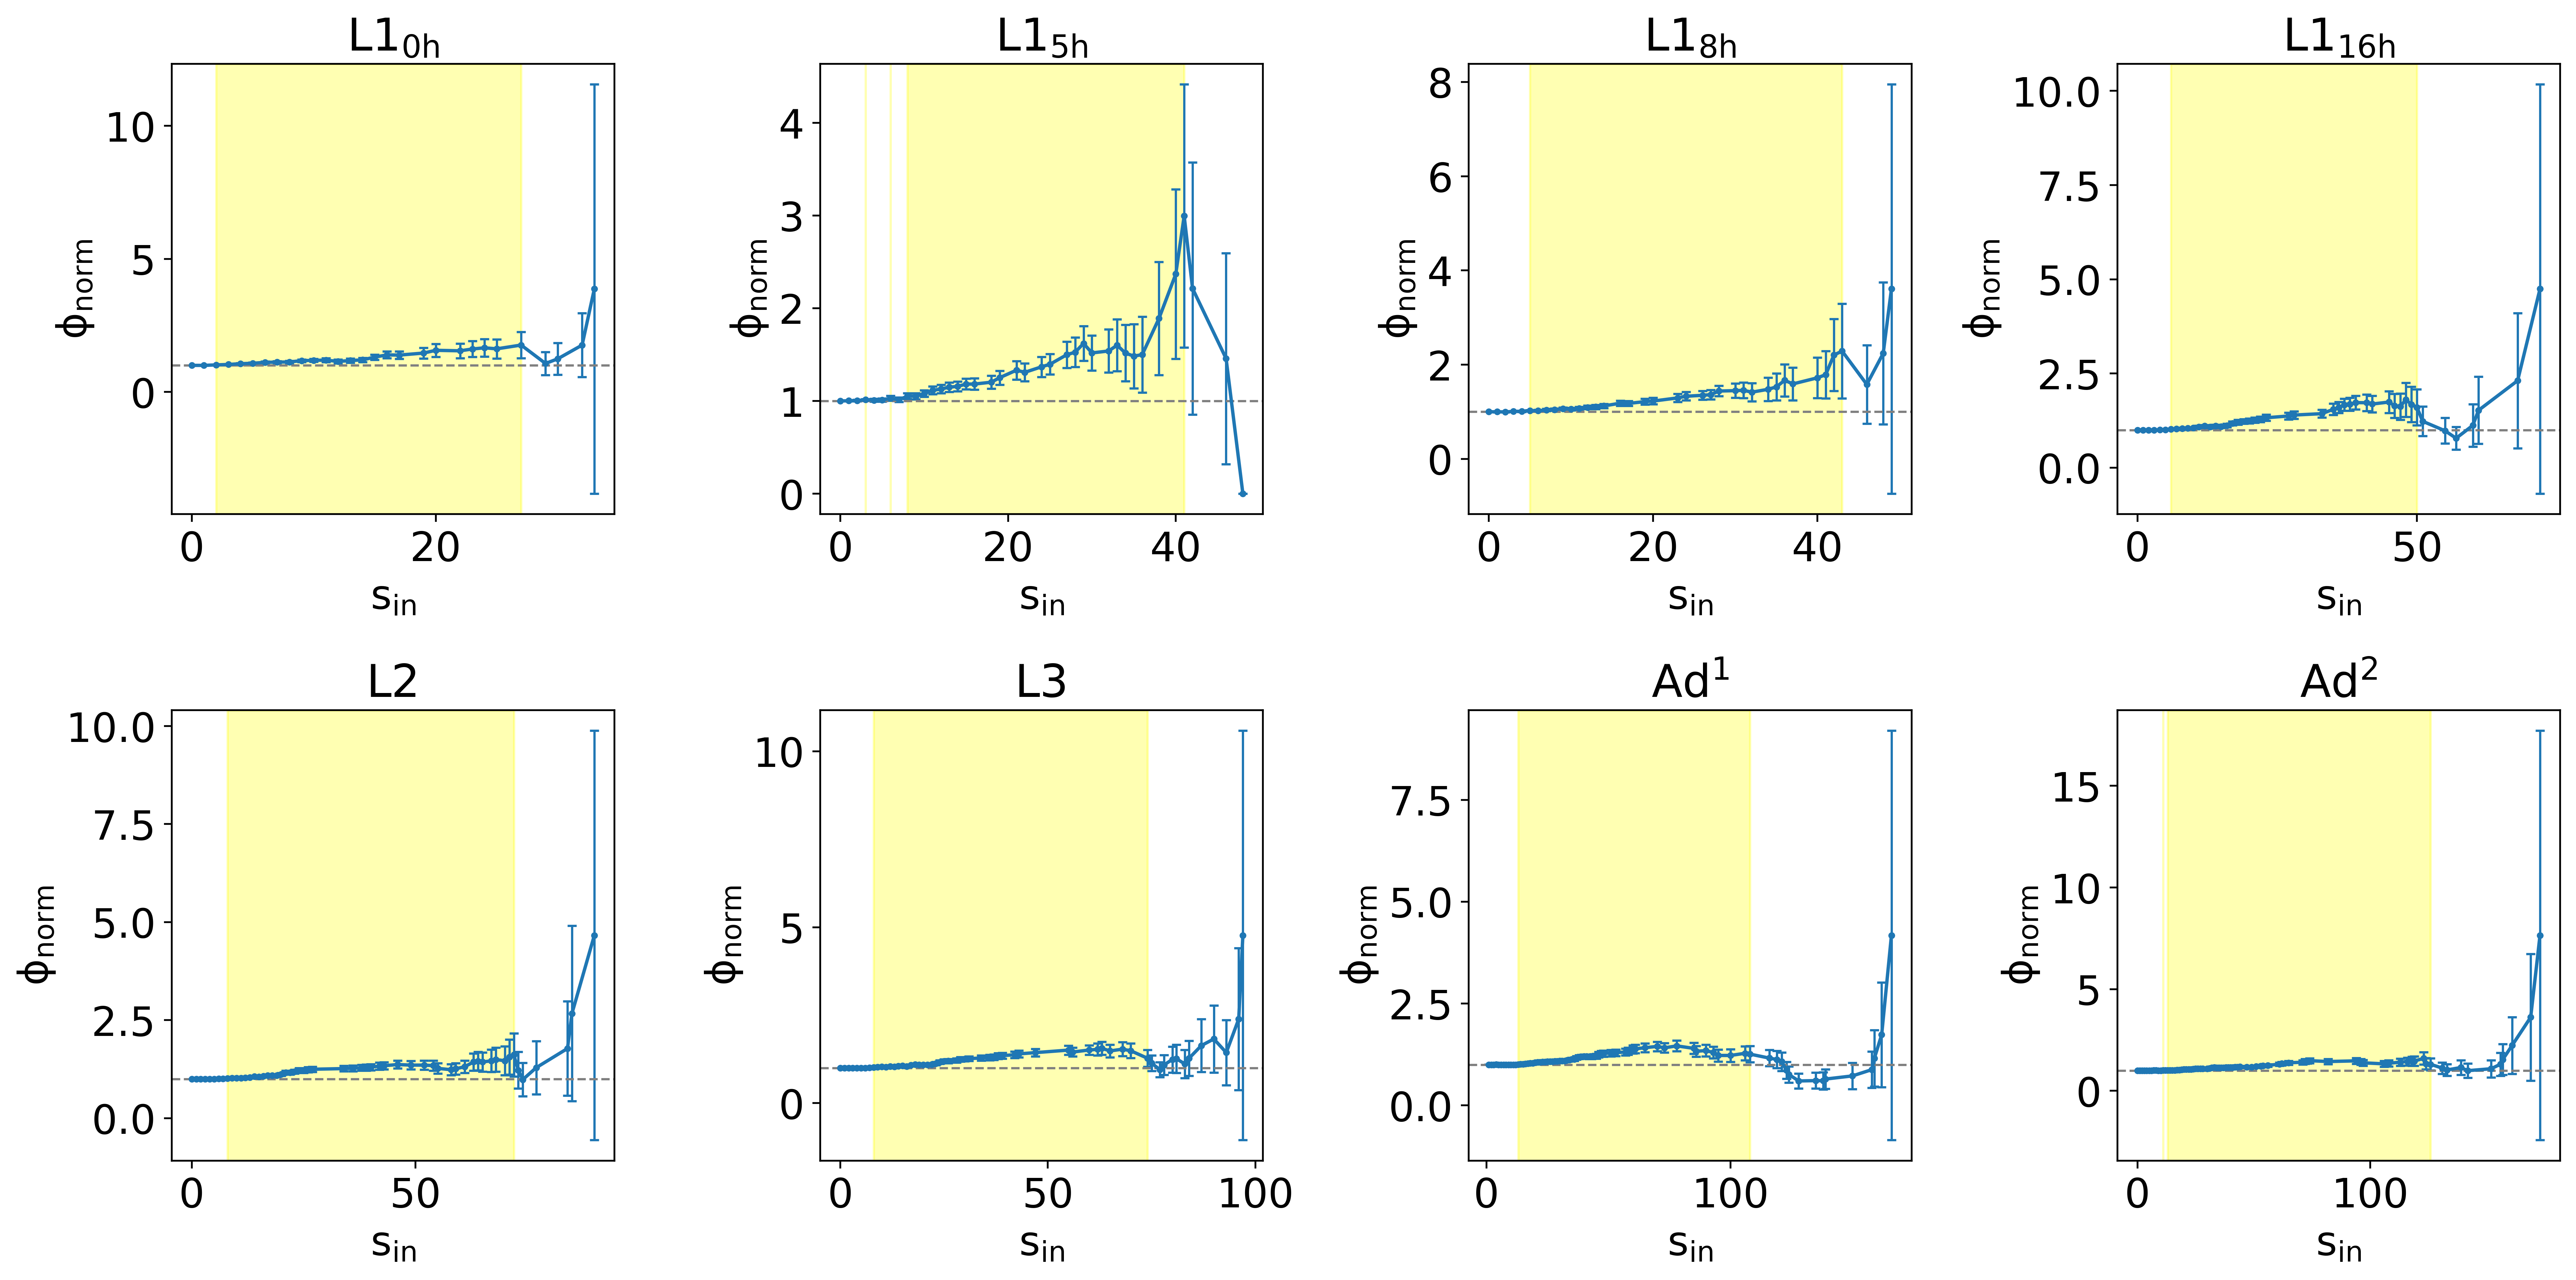

In [48]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=500)
axes = axes.flatten()

for i, data in enumerate(rich_club_data_in_degree):
    ax = axes[i]

    # Extract undefined k values for this stage
    undefined_k_vals = {k for k, _ in data['undefined']}

    # Separate defined and undefined points
    defined_k = []
    defined_phi = []
    defined_err = []

    for k, phi, err in zip(data['k_vals'], data['phi_norm'], data['phi_norm_err']):
        if k not in undefined_k_vals:
            defined_k.append(k)
            defined_phi.append(phi)
            defined_err.append(err)

    # Plot defined (normal) points with error bars
    ax.errorbar(defined_k, defined_phi, yerr=defined_err,
                fmt='o-', capsize=2, markersize=2, elinewidth=1, label=r'$\phi_{\mathrm{norm}}(k)$')

    # Plot undefined points at y=1 with open cyan circles (no error bars)
    for k, _ in data['undefined']:
        ax.plot(k, 1.0, marker='o', markersize=5, markerfacecolor='none',
                markeredgecolor='tab:blue', linestyle='None')

    # Add regime highlighting
    for start_k, end_k in stages_regimes_in_degree[i]:
        ax.axvspan(start_k, end_k, color='yellow', alpha=0.3)

    # Reference line at y = 1
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)

    ax.set_title(stage_labels_plot[i], fontsize=20)
    ax.set_xlabel("$s_{in}$", fontsize=18)
    ax.set_ylabel(r"$\phi_{\mathrm{norm}}$", fontsize=18)
    ax.tick_params(axis='both', labelsize=18)

plt.tight_layout(h_pad=2, w_pad=2)
plt.show()

## Plotting all stages for out-degree 

_In my algorithm, I have taken subgraphs of nodes having degree greater than k. There's no consistency in the literature regarding this. I have followed the Towlson paper on C. elegans rich club (same way done in "Rich-Club Organization of the Human Connectome"). But in "Rich-club neurocircuitry: function, evolution, and vulnerability" they have taken nodes with degree >= k. So, I think, either is fine._

In [26]:
# this took at least an hour AFAIR

rich_club_data = []
undefined_norm_RCC = {}
for i in range(8):
    empirical_graph = all_c_elegans_weighted_graphs[i]
    random_graphs = all_randomized_graphs_lists[i]

    weighted_out_degrees = dict(empirical_graph.out_degree(weight='weight'))
    unique_sin_vals = sorted(set(int(d) for d in weighted_out_degrees.values()))

    phi_norm = []
    phi_norm_err = []
    valid_k_vals = []
    undefined = []

    for k in unique_sin_vals:
        rich_nodes_emp = [n for n, d in weighted_out_degrees.items() if d > k]
        if len(rich_nodes_emp) < 2:
            continue

        subgraph_emp = empirical_graph.subgraph(rich_nodes_emp)
        w_emp = sum(d['weight'] for u, v, d in subgraph_emp.edges(data=True))

        rand_sums = []
        for G in random_graphs:
            weighted_out_degrees_rand = dict(G.out_degree(weight='weight'))
            rich_nodes_rand = [n for n, d in weighted_out_degrees_rand.items() if d > k]
            subgraph_rand = G.subgraph(rich_nodes_rand)
            w_rand = sum(d['weight'] for u, v, d in subgraph_rand.edges(data=True))
            rand_sums.append(w_rand)

        mean_rand = np.mean(rand_sums)
        std_rand = np.std(rand_sums)

        if mean_rand > 0:
            ratio = w_emp / mean_rand
            err = ratio * (std_rand / mean_rand)
        else:
            ratio = 1 # setting this to 1 as per the paper, "Rich-club and page-club coefficients for directed graphs"
            err = 0
            undefined.append((k,  w_emp))
            
        valid_k_vals.append(k)
        phi_norm.append(ratio)
        phi_norm_err.append(err)

    rich_club_data.append({
        'stage': stage_labels[i],
        'k_vals': valid_k_vals,
        'phi_norm': phi_norm,
        'phi_norm_err': phi_norm_err,
        'undefined': undefined
    })

#with open("data/processed/C_elegans_normalized_out_degree_weighted_rcc_all_networks.pkl", "wb") as f:
    #pickle.dump(rich_club_data, f)



In [32]:
with open("data/processed/C_elegans_normalized_out_degree_weighted_rcc_all_networks.pkl", "rb") as f:
    rich_club_data_out_degree = pickle.load(f)

In [34]:
rich_club_data_out_degree

[{'stage': 'L1-0',
  'k_vals': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   18,
   19,
   20,
   22,
   29],
  'phi_norm': [1.001700199822633,
   1.0029755288582465,
   1.0062838989200724,
   1.0057352299887945,
   0.9947664034705497,
   1.0101678982145477,
   1.030668599687695,
   1.02247378621105,
   1.1202660573417185,
   1.1175544375744078,
   1.204084078848438,
   1.212243660975856,
   1.3489489811415147,
   1.3007469132666023,
   1.113645511874413,
   0.9696542301165788,
   1.0584301556373434,
   1.236138883839302,
   1.1360050489113285,
   1.2880739505985754,
   1.8525379770285293,
   1.9524894240156199],
  'phi_norm_err': [0.0017131871973971287,
   0.004192473100368147,
   0.007160229083120868,
   0.006816778113445014,
   0.010481371350994058,
   0.0147868007383295,
   0.018315721848139697,
   0.033100914298859,
   0.04896618080797015,
   0.06053756940160858,
   0.08182420940076886,
   0.11080570977398917,
   0.13

In [25]:
# phi_norm is never 0 for any stage so we can say that mean_random_rcc also was never 0 for any stage
for idx, stage_rcc_dict in enumerate(rich_club_data_out_degree):
    phi_norm = stage_rcc_dict['phi_norm']
    if 0 in set(phi_norm):
        print(stage_labels[idx], ' has a threshold for which phi norm is 0')

### Degree threshold for rich club phenomenon is found using those values of k for which we see that  $ \phi_{norm(k)} - \sigma_{\phi_{norm(k)}} > 1 $ . This is similar to the method used in the towlson paper (The Rich Club of the C.elegans Neuronal Connectome) . 

In [26]:
# initiallly regime is CLOSED so at every step check if statement is True then add the idx and make regime 'OPEN' 
# then close the regime at the first instance of idx where statement is False
# repeat the above

In [36]:
def pair_up(lst):
    
    '''Given a list of numbers, this function pairs up the items into tuples. Second element of the last tuple is None in
       case the list has odd number of items. '''
    
    paired = []
    for i in range(0, len(lst), 2):
        first = lst[i]
        second = lst[i+1] if i+1 < len(lst) else None
        paired.append((first, second))
    return paired


In [38]:
stages_regimes_out_degree = []
for dictionary in rich_club_data_out_degree:
    stage = dictionary['stage']
    size = len(dictionary['k_vals'])
    regime = 'CLOSE'
    all_regimes = []
    for idx in range(size):
        norm, err = dictionary['phi_norm'][idx], dictionary['phi_norm_err'][idx]
        statement = bool( (norm - err) >= 1)
            
        if regime == 'CLOSE' and statement == True:
            degree = dictionary['k_vals'][idx]
            all_regimes.append(degree)
            regime = 'OPEN'
            
        if regime == 'OPEN' and statement == False:
            degree = dictionary['k_vals'][idx-1]
            all_regimes.append(degree)
            regime = 'CLOSE'
        
    
    undefined_degree_points = [k for (k, _) in dictionary['undefined']]
    print(stage, all_regimes, undefined_degree_points)
    
    # confirming that undefined norm rcc is not mistakenly appearing in the middle of a regime. It's not. 
    if undefined_degree_points == True and all_regimes[-1] > min(undefined_degree_points): 
        print('\t', 'WARNING', undefined_degree_points)
        
    # Then I check the end of the last regime gives undefined norm RCC & if it does then I pop it out before pairing into tuples
    if undefined_degree_points:
        all_regimes.pop()
        
    print('    ', all_regimes)
    all_regimes = pair_up(all_regimes)
    stages_regimes_out_degree.append(all_regimes)
    
    print(all_regimes)
    print('\n')

L1-0 [6, 6, 8, 13] []
     [6, 6, 8, 13]
[(6, 6), (8, 13)]


L1-5 [7, 7, 11, 20] []
     [7, 7, 11, 20]
[(7, 7), (11, 20)]


L1-8 [6, 6, 12, 22] []
     [6, 6, 12, 22]
[(6, 6), (12, 22)]


L1-16 [9, 22, 25, 27] []
     [9, 22, 25, 27]
[(9, 22), (25, 27)]


L2 [9, 9, 17, 40, 58, 58] []
     [9, 9, 17, 40, 58, 58]
[(9, 9), (17, 40), (58, 58)]


L3 [5, 6, 28, 44, 68, 72] []
     [5, 6, 28, 44, 68, 72]
[(5, 6), (28, 44), (68, 72)]


Ad-45-1 [20, 20, 24, 24, 27, 29, 31, 31, 33, 68, 73, 73] []
     [20, 20, 24, 24, 27, 29, 31, 31, 33, 68, 73, 73]
[(20, 20), (24, 24), (27, 29), (31, 31), (33, 68), (73, 73)]


Ad-45-2 [32, 33, 35, 78, 104, 104] []
     [32, 33, 35, 78, 104, 104]
[(32, 33), (35, 78), (104, 104)]




### Plots with rich club regime dilineated

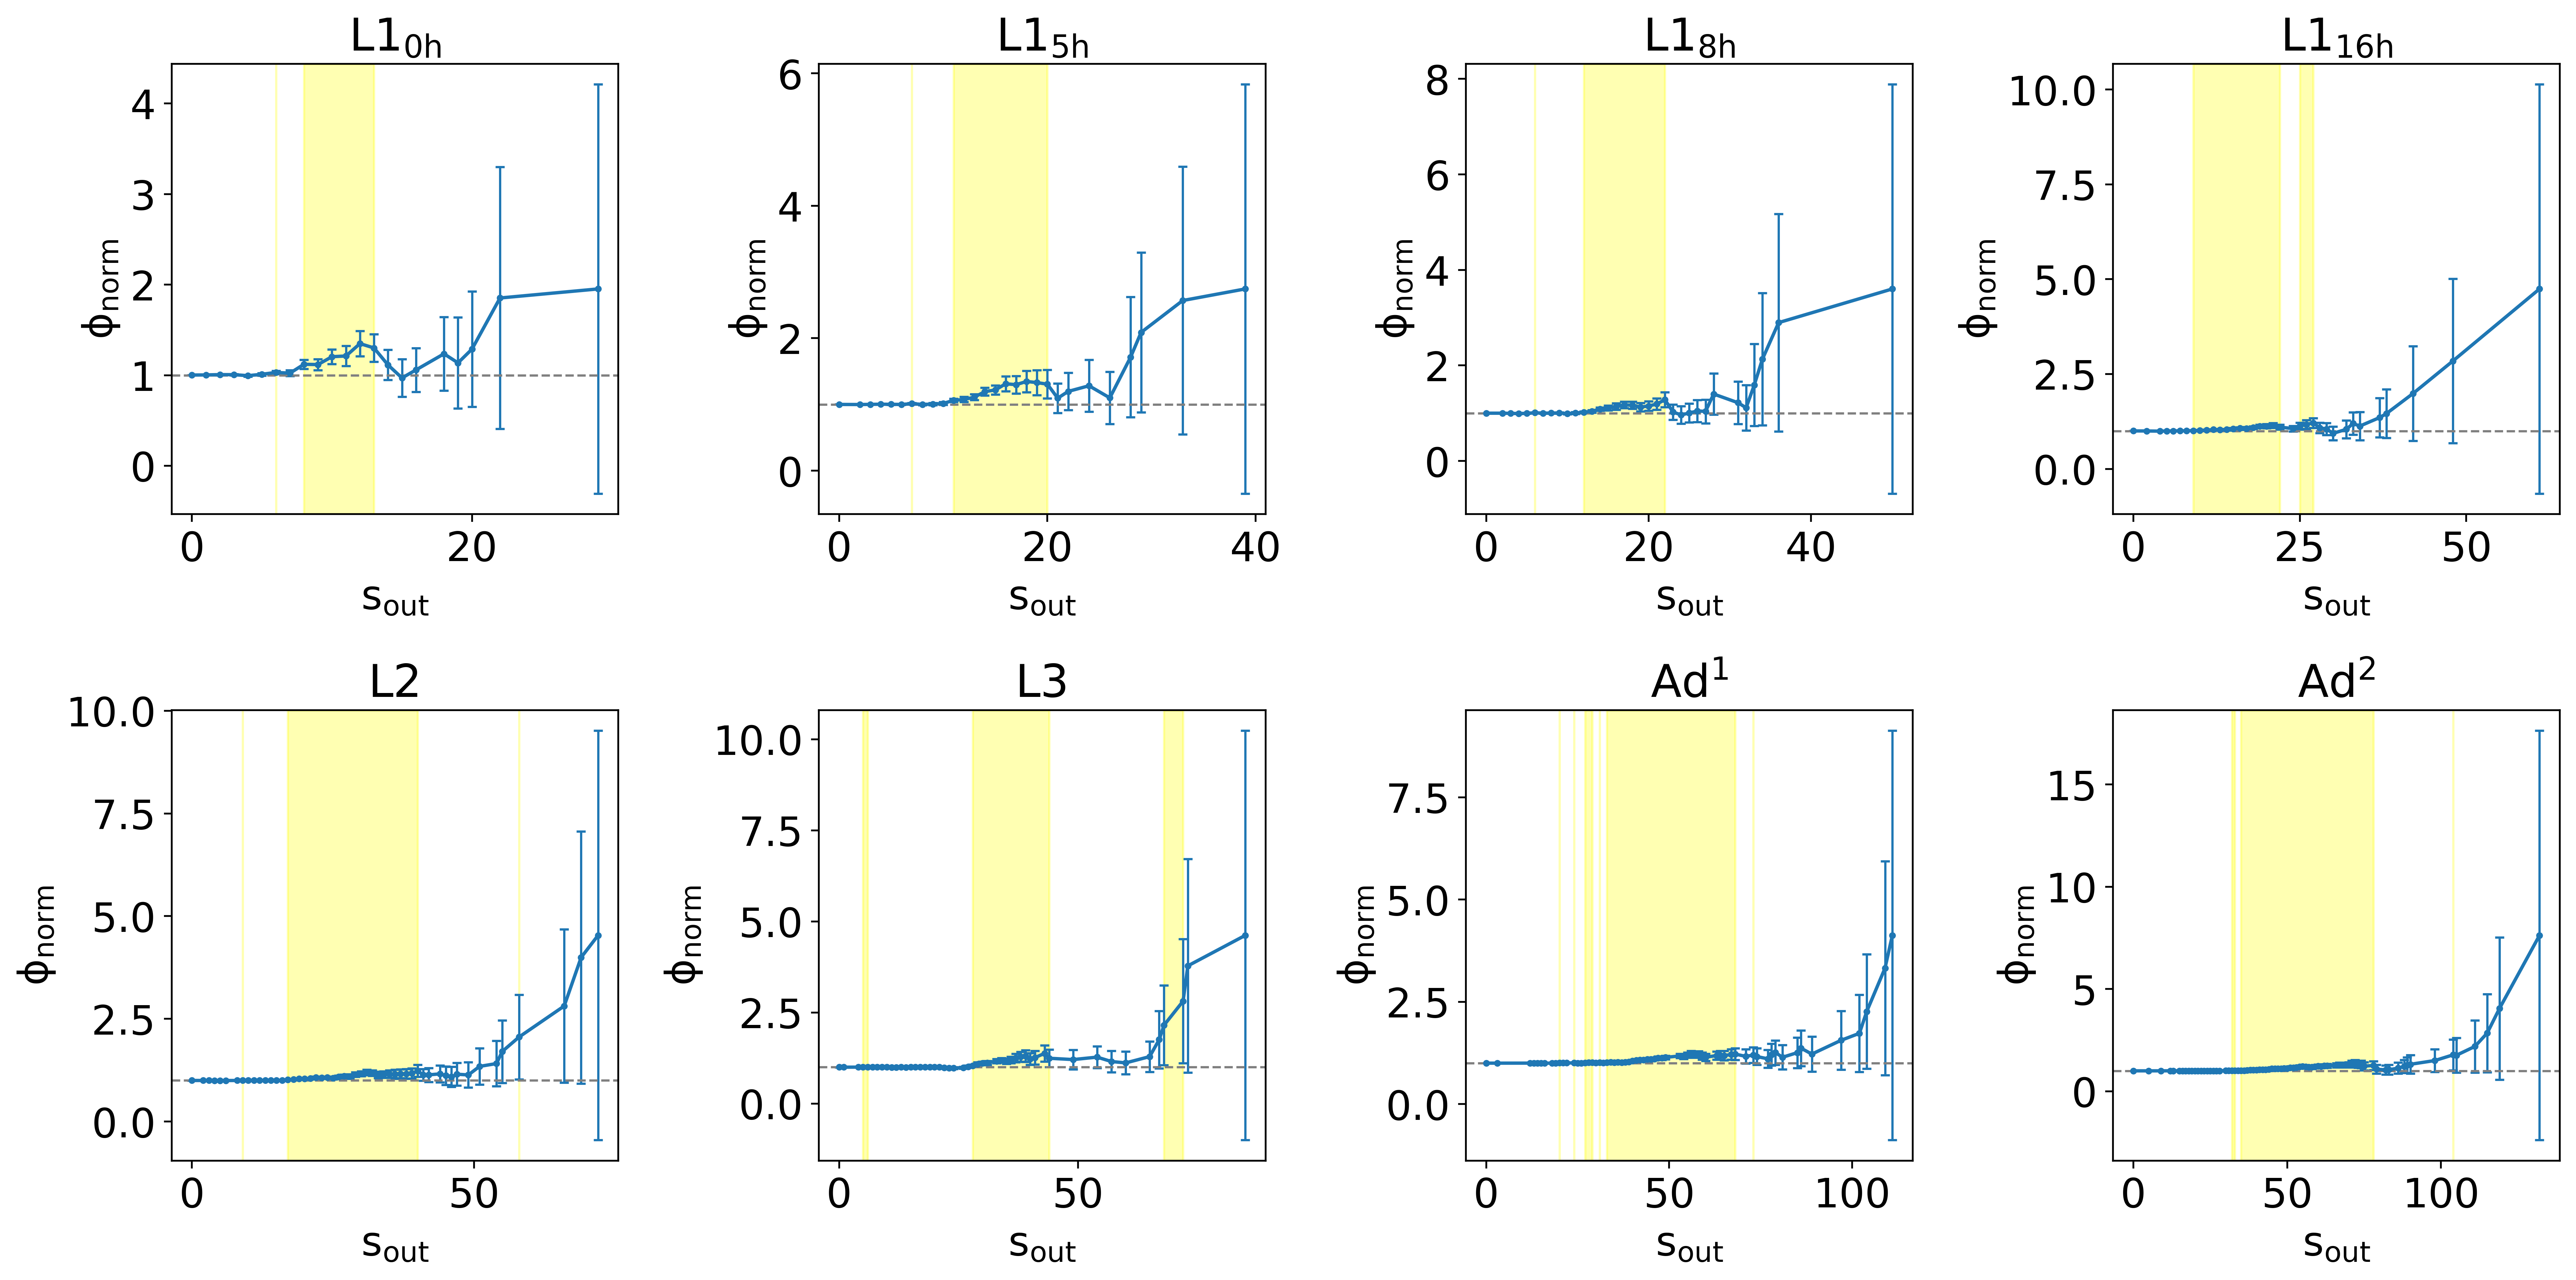

In [50]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=500)
axes = axes.flatten()

for i, data in enumerate(rich_club_data_out_degree):
    ax = axes[i]

    # Extract undefined k values for this stage
    undefined_k_vals = {k for k, _ in data['undefined']}

    # Separate defined and undefined points
    defined_k = []
    defined_phi = []
    defined_err = []

    for k, phi, err in zip(data['k_vals'], data['phi_norm'], data['phi_norm_err']):
        if k not in undefined_k_vals:
            defined_k.append(k)
            defined_phi.append(phi)
            defined_err.append(err)

    # Plot defined (normal) points with error bars
    ax.errorbar(defined_k, defined_phi, yerr=defined_err,
                fmt='o-', capsize=2, markersize=2, elinewidth=1, label=r'$\phi_{\mathrm{norm}}(k)$')

    # Plot undefined points at y=1 with open cyan circles (no error bars)
    for k, _ in data['undefined']:
        ax.plot(k, 1.0, marker='o', markersize=5, markerfacecolor='none',
                markeredgecolor='tab:blue', linestyle='None')

    # Add regime highlighting
    for start_k, end_k in stages_regimes_out_degree[i]:
        ax.axvspan(start_k, end_k, color='yellow', alpha=0.3)

    # Reference line at y = 1
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)

    ax.set_title(stage_labels_plot[i], fontsize=20)
    ax.set_xlabel("$s_{out}$", fontsize = 18)
    ax.set_ylabel(r"$\phi_{\mathrm{norm}}$", fontsize = 18)
    ax.tick_params(axis='both', labelsize=18)

plt.tight_layout(h_pad=2, w_pad=2)
plt.show()

In [45]:
dir_Wtd_RC_regimes = {'weighted in-degree': stages_regimes_in_degree,
                     'weighted out-degree': stages_regimes_out_degree}

In [47]:
#with open('data/processed/C_elegans_Dir_Wtd_RC_Regimes.pkl', 'wb') as file:
    #pickle.dump(dir_Wtd_RC_regimes, file)

### Obtaining the Rich Clubs using the lowest threshold (the largest RC, thus)
### Then, plotting intersections with k-cores and s-cores

In [13]:
rich_clubs_in_degree_all_stages = {}
for idx, network in enumerate(all_c_elegans_weighted_graphs):
    threshold = stages_regimes_in_degree[idx][0][0]
    in_degrees = dict(network.in_degree(weight='weight'))
    RC = {node for node in network.nodes() if in_degrees[node] > threshold}
    rich_clubs_in_degree_all_stages[idx] = RC
    print(f"threshold: {threshold}, RC size: {len(RC)}, Network Size: {network.number_of_nodes()} \n")

threshold: 2, RC size: 118, Network Size: 187 

threshold: 3, RC size: 131, Network Size: 193 

threshold: 5, RC size: 108, Network Size: 198 

threshold: 6, RC size: 112, Network Size: 203 

threshold: 8, RC size: 120, Network Size: 210 

threshold: 8, RC size: 130, Network Size: 216 

threshold: 13, RC size: 147, Network Size: 221 

threshold: 11, RC size: 164, Network Size: 219 



In [14]:
rich_clubs_out_degree_all_stages = {}
for idx, network in enumerate(all_c_elegans_weighted_graphs):
    threshold = stages_regimes_out_degree[idx][0][0]
    out_degrees = dict(network.out_degree(weight='weight'))
    RC = {node for node in network.nodes() if out_degrees[node] > threshold}
    rich_clubs_out_degree_all_stages[idx] = RC
    print(f"threshold: {threshold}, RC size: {len(RC)}, Network Size: {network.number_of_nodes()} \n")

threshold: 6, RC size: 95, Network Size: 187 

threshold: 7, RC size: 113, Network Size: 193 

threshold: 6, RC size: 122, Network Size: 198 

threshold: 9, RC size: 117, Network Size: 203 

threshold: 9, RC size: 142, Network Size: 210 

threshold: 5, RC size: 151, Network Size: 216 

threshold: 20, RC size: 138, Network Size: 221 

threshold: 32, RC size: 112, Network Size: 219 



In [19]:
#with open('data/processed/C_elegans_rich_clubs_weighted_in_degree_all_stages.pkl', 'wb') as file:
    #pickle.dump(rich_clubs_in_degree_all_stages, file)
    
#with open('data/processed/C_elegans_rich_clubs_weighted_out_degree_all_stages.pkl', 'wb') as file:
    #pickle.dump(rich_clubs_out_degree_all_stages, file)